# Imports

In [19]:
%reload_ext autoreload
%autoreload 2


import os
import sys
import imagehash
from PIL import Image
from tqdm import tqdm
import numpy as np
import torch
from IPython.display import display
from PIL import Image
from torchvision.utils import draw_segmentation_masks


from ftdinosaur_inference import build_dinosaur, utils


# local imports
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(''))))
from occam.submodules.dino_ft_wrapper import (
    load_model,
    get_masks_as_image,
    overlay_masks_on_image,
    prep_for_display,
    get_cmap
)
from occam.get_segments.run_cropformer import EntitySegDecoder
sys.path.pop(0)


from stuned.utility.utils import (
    get_project_root_path
)


CONF_THRESHOLD = 0.5

# Functions

In [20]:
# show images with masks overlayed
def show_cropformer_mask_overlay(image_tensor, output_mask, alpha=0.6):

    num_masks = int(output_mask.max()) + 1
    masks_as_image = torch.zeros(
        (num_masks, output_mask.shape[0], output_mask.shape[1])
    ).to(torch.bool)
    for mask_value in range(num_masks):
        masks_as_image[mask_value] = torch.Tensor(output_mask == mask_value)

    assert len(image_tensor.shape) == 4
    masks_on_image = draw_segmentation_masks(
        image_tensor[0].permute(2, 0, 1),
        masks_as_image,
        alpha=alpha,
        colors=get_cmap(num_masks)
    )

    # Convert back to PIL
    masks_on_image = masks_on_image.permute(1, 2, 0).numpy()
    image_to_show = Image.fromarray(masks_on_image.astype(np.uint8))
    return image_to_show


def show_cropformer_mask_overlay_from_path_list(model, path_list, alpha=0.6):
    model.eval()
    for path in path_list:
        image = Image.open(path).convert("RGB")
        image_tensor = torch.tensor(np.array(image).astype(np.uint8)).unsqueeze(0)
        output_mask = model(image_tensor)
        image_to_show = show_cropformer_mask_overlay(
            image_tensor,
            output_mask,
            alpha=alpha
        )
        display(image_to_show)


def show_dinosaur_mask_visualizations(image, output, alpha=0.6, show_soft_masks=True):
    masks = output["masks"] if isinstance(output, dict) else output
    num_masks = masks.shape[1]

    print("DINOSAUR mask overlay")
    display(overlay_masks_on_image(image, masks, num_masks=num_masks, alpha=alpha))

    print("DINOSAUR hard slot assignment")
    masks_as_image = get_masks_as_image(masks, height=image.height, width=image.width)
    display(prep_for_display(masks_as_image))

    if show_soft_masks:
        soft_masks = utils.resize_patches_to_image(
            masks,
            size=(image.height, image.width)
        ).squeeze(0)
        for mask_id, mask in enumerate(soft_masks):
            print(f"DINOSAUR soft mask {mask_id}")
            display(prep_for_display(mask))

    return masks_as_image


def compute_hashes(path_label_pairs, hash_func=imagehash.phash):
    # Compute hashes for each image
    hashes = []
    for path, _ in tqdm(path_label_pairs):
        try:
            img = Image.open(path)
            img_hash = hash_func(img)  # Choose a hash method, e.g., average hash
            hashes.append((path, img_hash))
        except Exception as e:
            print(f"Error processing {path}: {e}")
    return hashes


def count_near_duplicates(hashes, threshold=5, verbose=False):

    num_hashes = len(hashes)
    duplicates = {path: [path] for path, hash in hashes}

    for i in tqdm(range(num_hashes)):
        path_i, hash_i = hashes[i]
        if path_i not in duplicates:
            continue
        for j in range(i + 1, num_hashes):
            # Compute the Hamming distance between hashes

            path_j, hash_j = hashes[j]

            if hash_i - hash_j <= threshold:

                class_i = path_i.split(os.sep)[-2]
                class_j = path_j.split(os.sep)[-2]
                assert class_i == class_j, \
                    f"{class_i} != {class_j} for {path_i} and {path_j}"
                duplicates[path_i].append(path_j)
                if verbose:
                    print(
                        f"removing {j}-th {path_j} because "
                        f"it is similar to {i}-th {path_i}"
                    )
                duplicates.pop(path_j)

    return duplicates

# Predict with HQES

## From Figure 3

[GConvNet]: convert str gconv to func
[gconv] 2 order with dims= [96, 192] scale=0.3333
[gconv] 2 order with dims= [96, 192] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 

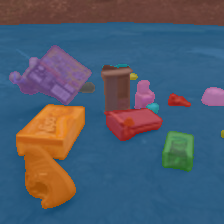

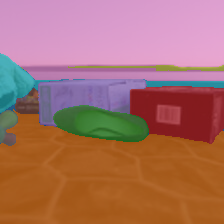

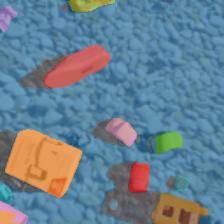

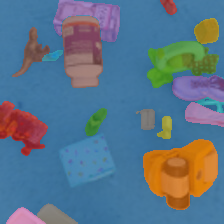

In [21]:
path_list = [
    os.path.join(get_project_root_path(), "figures", "images_from_ft_dino_paper", "011.jpg"),
    os.path.join(get_project_root_path(), "figures", "images_from_ft_dino_paper", "046.jpg"),
    os.path.join(get_project_root_path(), "figures", "images_from_ft_dino_paper", "055.jpg"),
    os.path.join(get_project_root_path(), "figures", "images_from_ft_dino_paper", "086.jpg"),
]
model = EntitySegDecoder(
    config_path=os.path.join(get_project_root_path(), "configs", "cropformer", "cropformer_hornet.yaml"),
    opts=["MODEL.WEIGHTS", os.path.join(get_project_root_path(), "checkpoints", "CropFormer_hornet_3x_03823a.pth")],
    confidence_threshold=CONF_THRESHOLD
)
show_cropformer_mask_overlay_from_path_list(model, path_list, alpha=0.6)

## From Figure 1

In [22]:
model = EntitySegDecoder(
    config_path=os.path.join(get_project_root_path(), "configs", "cropformer", "cropformer_hornet.yaml"),
    opts=["MODEL.WEIGHTS", os.path.join(get_project_root_path(), "checkpoints", "CropFormer_hornet_3x_03823a.pth")],
    confidence_threshold=CONF_THRESHOLD
)


[GConvNet]: convert str gconv to func
[gconv] 2 order with dims= [96, 192] scale=0.3333
[gconv] 2 order with dims= [96, 192] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 

### Bears example

In [23]:
bears_path = os.path.join(get_project_root_path(), "figures", "polar_bears.png")

In [24]:
image = Image.open(bears_path).convert("RGB")

In [25]:
image_tensor = torch.tensor(np.array(image).astype(np.uint8)).unsqueeze(0)
model.eval()
output_mask = model(image_tensor)

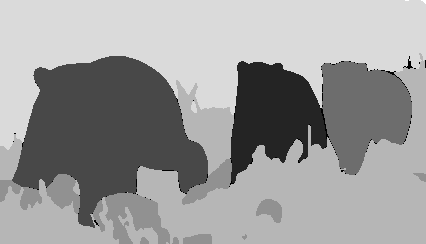

In [26]:
display(prep_for_display(torch.tensor(output_mask)))

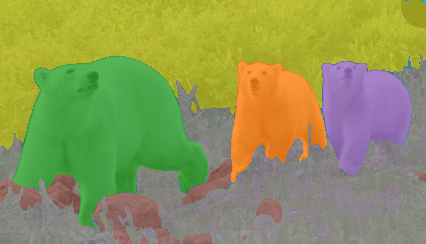

In [27]:
show_cropformer_mask_overlay_from_path_list(model, [bears_path], alpha=0.8)

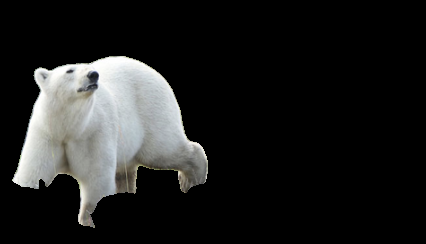

In [28]:
mask_tensor = torch.tensor(output_mask==2).unsqueeze(0).unsqueeze(3)
result = image_tensor * mask_tensor
result = result.squeeze(0).numpy()
result = Image.fromarray(result.astype(np.uint8))
display(result)

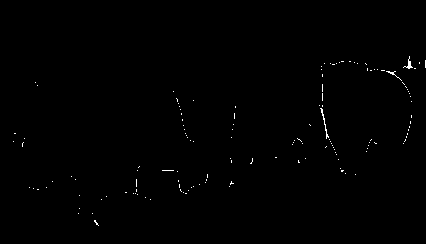

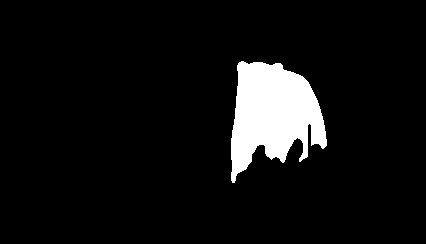

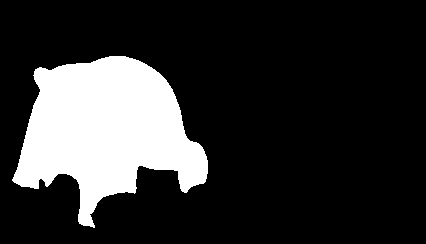

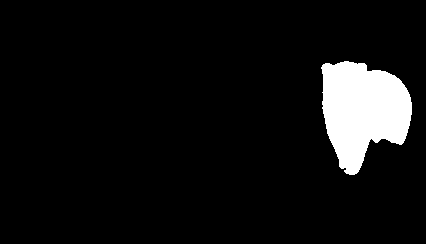

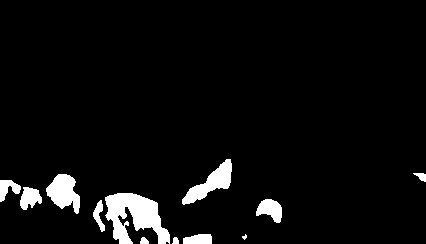

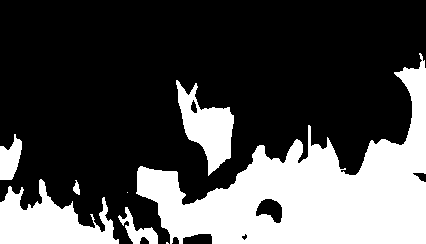

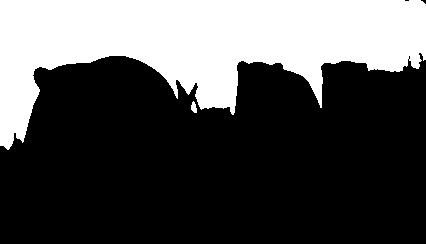

In [29]:
for i in range(7):
    display(prep_for_display(torch.tensor(output_mask==i)))

# Predict with FT-Dinosaur

In [30]:
model_name = "dinosaur_base_patch14_518_topk3.coco_dv2_ft_s7_300k+10k"
model = load_model(model_name)
preproc = build_dinosaur.build_preprocessing(model_name)

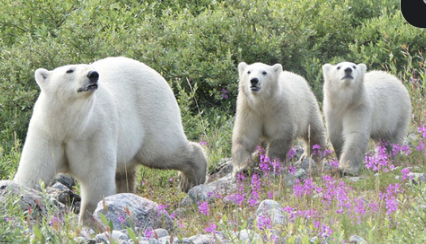

In [31]:
image = Image.open(os.path.join(get_project_root_path(), "figures", "polar_bears.png")).convert("RGB")
display(image)

In [32]:
with torch.no_grad():
    inp = preproc(image).unsqueeze(0)
    outp = model(inp, num_slots=5)

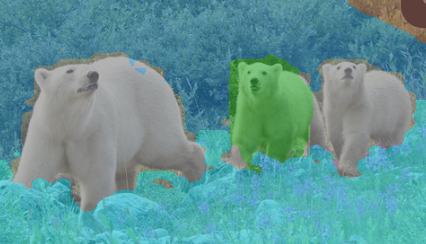

In [33]:
dinosaur_masks_as_image = show_dinosaur_mask_visualizations(
    image,
    outp,
    alpha=0.6,
    show_soft_masks=True
)

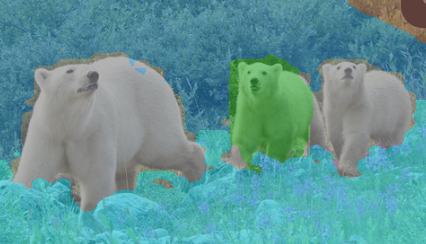

In [34]:
img = image
masks = outp["masks"]
num_masks = masks.shape[1]
alpha = 0.6

img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1)  # C x H x W
height, width = img_tensor.shape[1:]

# Need to resize masks to image (1 x K x P -> 1 x K x H x W)
masks_as_image = utils.resize_patches_to_image(masks, size=(height, width))
masks_as_image = utils.soft_masks_to_one_hot(masks_as_image).squeeze(0)

# Overlay masks on image
masks_on_image = draw_segmentation_masks(
    img_tensor, masks_as_image, alpha=alpha, colors=get_cmap(num_masks)
)

# Convert back to PIL
masks_on_image = masks_on_image.permute(1, 2, 0).numpy()
res = Image.fromarray(masks_on_image.astype(np.uint8))
display(res)

In [35]:
masks_as_image = get_masks_as_image(
    outp["masks"],
    height=image.height,
    width=image.width
)

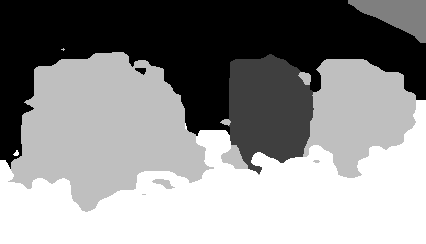

In [36]:
display(prep_for_display(masks_as_image))